<a href="https://colab.research.google.com/github/mariemshrief28-prog/Vision-Projects/blob/main/birds_planes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor

In [ ]:
data_path='../data-unversioned/p1ch7/'
train_data=datasets.CIFAR10(data_path,
                            train=True,
                            download=True)
test_data=datasets.CIFAR10(data_path,
                           train=False,
                           download=True
                           )

100%|██████████| 170M/170M [00:01<00:00, 99.3MB/s]


In [ ]:
len(train_data),len(test_data)

(50000, 10000)

In [ ]:
class_names=train_data.classes

In [ ]:
img,label=train_data[99]
img,label,class_names[label]

(<PIL.Image.Image image mode=RGB size=32x32>, 1, 'automobile')

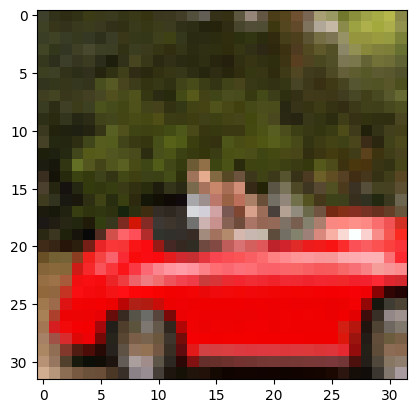

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

In [ ]:
data_path='../data-unversioned/p1ch7/'
train_data_t=datasets.CIFAR10(data_path,
                            train=True,
                            download=True,
                            transform=ToTensor())
test_data_t=datasets.CIFAR10(data_path,
                           train=False,
                           download=True,
                           transform=ToTensor())

In [ ]:
image,_=train_data_t[99]
image.shape

torch.Size([3, 32, 32])

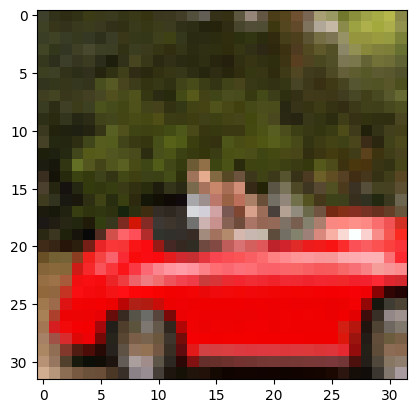

In [ ]:
plt.imshow(image.permute(1,2,0))
plt.show()

In [ ]:
imgs=torch.stack([image for image,_ in train_data_t ], dim=3)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [ ]:
imgs.view(3,-1).mean(dim=1)


tensor([0.4914, 0.4822, 0.4465])

In [ ]:
imgs.view(3,-1).std(dim=1)

tensor([0.2470, 0.2435, 0.2616])

In [ ]:
from torchvision import transforms
transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))

Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))

In [ ]:
transformed_train_data=datasets.CIFAR10(data_path,
                                        train=True,
                                        download=True,
                                        transform=transforms.Compose([
                                            transforms.ToTensor(),
                                            transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
                                        ]))

transformed_test_data=datasets.CIFAR10(data_path,
                                        train=False,
                                        download=True,
                                        transform=transforms.Compose([
                                            transforms.ToTensor(),
                                            transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
                                        ]))

In [ ]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [ ]:
label_map ={0:0 , 2:1}
class_names=['airplane','bird']
cifar2=[(img,label_map[label])
        for img ,label in transformed_train_data
        if label in[0,2]]
cifar2_val=[(img , label_map[label])
            for img , label in transformed_test_data
            if label in [0,2]]

In [ ]:
import torch.nn as nn
n_out=2

model = nn.Sequential(
nn.Linear(3072, 1024),
nn.Tanh(),
nn.Linear(1024, 512),
nn.Tanh(),
nn.Linear(512, 128),
nn.Tanh(),
nn.Linear(128, 2),
)

In [ ]:
def softmax(x):
  return torch.exp(x)/torch.exp(x).sum()


In [ ]:
x = torch.tensor([1.0, 2.0, 3.0])
softmax(x)

tensor([0.0900, 0.2447, 0.6652])

In [ ]:
train_loader=torch.utils.data.DataLoader(cifar2,batch_size=64,shuffle=True)

In [ ]:
from torch import optim
optimizer=optim.SGD(model.parameters(),lr=4e-3)
loss_fn=nn.CrossEntropyLoss()
n_epochs=100
for epoch in range(n_epochs):
  epoch_loss=0
  for imgs,labels in train_loader:
    batch_size=imgs.shape[0]
    optimizer.zero_grad()
    out=model(imgs.view(batch_size,-1))
    loss=loss_fn(out,labels)

    loss.backward()
    optimizer.step()
    epoch_loss += loss.item()
  print("Epoch: %d, Loss: %f" % (epoch, epoch_loss / len(train_loader)))

Epoch: 0, Loss: 0.560264
Epoch: 1, Loss: 0.506141
Epoch: 2, Loss: 0.491586
Epoch: 3, Loss: 0.481006
Epoch: 4, Loss: 0.472698
Epoch: 5, Loss: 0.465530
Epoch: 6, Loss: 0.459740
Epoch: 7, Loss: 0.452659
Epoch: 8, Loss: 0.448529
Epoch: 9, Loss: 0.443819
Epoch: 10, Loss: 0.438826
Epoch: 11, Loss: 0.433831
Epoch: 12, Loss: 0.429030
Epoch: 13, Loss: 0.423941
Epoch: 14, Loss: 0.419813
Epoch: 15, Loss: 0.415969
Epoch: 16, Loss: 0.411761
Epoch: 17, Loss: 0.407381
Epoch: 18, Loss: 0.402699
Epoch: 19, Loss: 0.399064
Epoch: 20, Loss: 0.393539
Epoch: 21, Loss: 0.387979
Epoch: 22, Loss: 0.385292
Epoch: 23, Loss: 0.381227
Epoch: 24, Loss: 0.374536
Epoch: 25, Loss: 0.369927
Epoch: 26, Loss: 0.364523
Epoch: 27, Loss: 0.362745
Epoch: 28, Loss: 0.356076
Epoch: 29, Loss: 0.348950
Epoch: 30, Loss: 0.350241
Epoch: 31, Loss: 0.342967
Epoch: 32, Loss: 0.340045
Epoch: 33, Loss: 0.332037
Epoch: 34, Loss: 0.324368
Epoch: 35, Loss: 0.319119
Epoch: 36, Loss: 0.312833
Epoch: 37, Loss: 0.310038
Epoch: 38, Loss: 0.309

In [ ]:
test_loader=torch.utils.data.DataLoader(cifar2_val,batch_size=64,shuffle=False)

In [ ]:
correct=0
total=0
with torch.no_grad():
  for imgs,labels in test_loader:
    batch_size=imgs.shape[0]
    outputs = model(imgs.view(batch_size, -1))
    _,predicted = torch.max(outputs ,dim=1)
    total+= labels.shape[0]
    correct+=int((predicted==labels).sum())

print("Accuracy: %f", correct / total)

Accuracy: %f 0.804


CNN

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(3,16,kernel_size=3,padding=1)
    self.act1=nn.Tanh()
    self.pool1=nn.MaxPool2d(2)
    self.conv2=nn.Conv2d(16,8,kernel_size=3,padding=1)
    self.act2=nn.Tanh()
    self.pool2=nn.MaxPool2d(2)
    self.fc1=nn.Linear(8*8*8,32)
    self.act3=nn.Tanh()
    self.fc2=nn.Linear(32,2)

  def forward(self,x):
    out=self.pool1(self.act1(self.conv1(x)))
    out=self.pool2(self.act2(self.conv2(out)))
    out=out.view(-1,8*8*8)
    out=self.act3(self.fc1(out))
    out=self.fc2(out)
    return out


In [ ]:
import datetime
def training_loop(n_epochs,optimizer, model, loss_fn , train_loader):
  for epoch in range(1 , n_epochs+1):
    loss_train=0
    for imgs,labels in train_loader:
      outputs=model(imgs)
      loss=loss_fn(outputs,labels)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      loss_train+=loss.item()
    if epoch==1 or epoch%10==0  :
      print('{} Epoch {}, Training loss {}'.format(
         datetime.datetime.now(), epoch,
         loss_train / len(train_loader)))

In [ ]:
model=Net()
optimizer=optim.SGD(model.parameters(),lr=1e-2)
loss_fn=nn.CrossEntropyLoss()
training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
)

2026-04-11 12:17:09.161769 Epoch 1, Training loss 0.5799093876674677
2026-04-11 12:17:46.527781 Epoch 10, Training loss 0.3375308170060443
2026-04-11 12:18:28.772097 Epoch 20, Training loss 0.3058801464214446
2026-04-11 12:19:10.100971 Epoch 30, Training loss 0.2815393319555149
2026-04-11 12:19:51.976837 Epoch 40, Training loss 0.25787587748591306
2026-04-11 12:20:36.208398 Epoch 50, Training loss 0.23594209993151344
2026-04-11 12:21:18.514227 Epoch 60, Training loss 0.21450681210892975
2026-04-11 12:22:00.562440 Epoch 70, Training loss 0.19726764875802266
2026-04-11 12:22:42.898923 Epoch 80, Training loss 0.1804810136936273
2026-04-11 12:23:24.645057 Epoch 90, Training loss 0.16659273639036593
2026-04-11 12:24:06.145365 Epoch 100, Training loss 0.1493879231108222


In [ ]:
def validate(model , train_loader , test_loader):
  for name,loader in [("train",train_loader),("val",test_loader)]:
    correct=0
    total=0
    with torch.no_grad():
      for imgs,labels in loader:
        outputs=model(imgs)
        _,predicted = torch.max(outputs,dim=1)
        total+=labels.shape[0]
        correct+=int((predicted==labels).sum())
    print("Accuracy {}: {:.2f}".format(name , correct / total))


In [ ]:
validate(model, train_loader, test_loader)

Accuracy train: 0.94
Accuracy val: 0.90
